In [ ]:
!pip install kaggle
!mkdir -p /data
!chmod 777 /data
!cd data
!kaggle datasets download -d derrickmwiti/google-2019-cluster-sample
!unzip google-2019-cluster-sample.zip
!cd ..

In [1]:
import ast
import json

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
machine_events = pd.read_csv("/home/maria/Projects/BigData_labs/lab_1/data/borg_traces_data.csv")
machine_events.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


Split the dataset to the train (20%) val (10%) and streaming simulation (70%) data

In [3]:
train_df, temp_df = train_test_split(
    machine_events,
    test_size=0.8,
    stratify=machine_events["failed"],
    random_state=42
)

val_df, stream_df = train_test_split(
    temp_df,
    test_size=0.875,
    stratify=temp_df["failed"],
    random_state=42
)

stream_df = stream_df.sort_values("time")
stream_df = stream_df.drop(columns=["failed", "instance_events_type", "collections_events_type", "event"])

In [4]:
print(machine_events["failed"].mean())
print(train_df["failed"].mean())
print(val_df["failed"].mean())

0.22833054935525038
0.22832540836187143
0.22833772697036142


In [5]:
train_df.to_parquet("/home/maria/Projects/BigData_labs/lab_1/data/split/train_raw.parquet", index=False)
val_df.to_parquet("/home/maria/Projects/BigData_labs/lab_1/data/split/val_raw.parquet", index=False)
stream_df.to_parquet("/home/maria/Projects/BigData_labs/lab_1/data/split/stream_raw.parquet", index=False)

### EDA

Remove uninformative columns

In [6]:
events = machine_events.drop(["Unnamed: 0", "collection_id", "alloc_collection_id", "collection_name", "collection_logical_name", "user", "instance_index", "start_after_collection_ids"], axis=1)
events.columns

Index(['time', 'instance_events_type', 'scheduling_class', 'collection_type',
       'priority', 'machine_id', 'resource_request', 'constraint',
       'collections_events_type', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='str')

In [7]:
events.describe()

,time,instance_events_type,scheduling_class,collection_type,priority,machine_id,collections_events_type,vertical_scaling,scheduler,start_time,end_time,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cluster,failed
count,4.058940e+05,405894.000000,405894.000000,405894.000000,405894.000000,4.058940e+05,405894.000000,404935.000000,404935.000000,4.058940e+05,4.058940e+05,405894.000000,405894.000000,281206.000000,281206.000000,405894.000000,405894.000000,405894.000000
mean,6.927465e+13,2.945983,1.266870,0.087782,147.913793,8.491885e+10,2.945983,1.858740,0.370422,1.238422e+12,1.238634e+12,0.008927,0.000398,2.185379,0.010722,0.999223,4.563613,0.228331
std,2.507511e+16,2.045794,1.014087,0.282977,116.656633,1.377903e+11,2.045794,0.754768,0.482918,7.965088e+11,7.965134e+11,0.024937,0.000550,1.256117,0.007753,0.010239,2.208008,0.419757
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,0.000000,1.000000,0.000000,3.000000e+08,6.000000e+08,0.000000,0.000000,0.252846,0.000125,0.110000,1.000000,0.000000
25%,2.674747e+11,2.000000,0.000000,0.000000,103.000000,2.932044e+09,2.000000,1.000000,0.000000,5.219700e+11,5.219710e+11,0.000196,0.000008,1.067229,0.004329,1.000000,3.000000,0.000000
50%,1.084800e+12,3.000000,1.000000,0.000000,105.000000,2.008985e+10,3.000000,2.000000,0.000000,1.274400e+12,1.274509e+12,0.002693,0.000227,1.918681,0.009506,1.000000,5.000000,0.000000
75%,1.766117e+12,5.000000,2.000000,0.000000,200.000000,1.318590e+11,5.000000,2.000000,1.000000,1.944000e+12,1.944300e+12,0.006683,0.000539,3.156894,0.016435,1.000000,6.000000,0.000000
max,9.223372e+18,10.000000,3.000000,1.000000,450.000000,8.254274e+11,10.000000,3.000000,1.000000,2.678400e+12,2.678700e+12,0.286133,0.008453,105.275932,0.084292,1.000000,8.000000,1.000000


Check class imbalance

In [8]:
events["failed"].value_counts(normalize=True)

failed
0    0.771669
1    0.228331
Name: proportion, dtype: float64

Remove repetitive information

In [9]:
events[["instance_events_type", "collections_events_type", "event", "failed"]].head()

,instance_events_type,collections_events_type,event,failed
0,2,2,FAIL,1
1,2,2,FAIL,1
2,6,6,SCHEDULE,0
3,2,2,FAIL,1
4,3,3,FINISH,0


In [10]:
pd.crosstab(events["event"], events["failed"])

failed,0,1
event,,
ENABLE,75907,0
EVICT,14756,0
FAIL,0,92678
FINISH,92867,0
KILL,951,0
LOST,59515,0
QUEUE,4,0
SCHEDULE,69104,0
UPDATE_PENDING,111,0


Keeping several of these with the actual answer "failed" will lead to leakage, which can lead to overly confident predictions based only on one feature

In [11]:
events = events.drop(["instance_events_type", "collections_events_type", "event"], axis=1)

Parse CPU and memory usage from dicts

In [12]:
events.loc[:, ["resource_request", "average_usage", "maximum_usage", "random_sample_usage"]].head()

,resource_request,average_usage,maximum_usage,random_sample_usage
0,"{'cpus': 0.020660400390625, 'memory': 0.014434...","{'cpus': 0.00466156005859375, 'memory': 0.0059...","{'cpus': 0.01190185546875, 'memory': 0.0059356...","{'cpus': 0.0043487548828125, 'memory': None}"
1,"{'cpus': 0.00724029541015625, 'memory': 0.0013...","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': None}"
2,"{'cpus': 0.048583984375, 'memory': 0.004165649...","{'cpus': 0.024200439453125, 'memory': 0.002788...","{'cpus': 0.06005859375, 'memory': 0.0028457641...","{'cpus': 0.026458740234375, 'memory': None}"
3,"{'cpus': 0.0704345703125, 'memory': 0.04162597...","{'cpus': 0.047607421875, 'memory': 0.034423828...","{'cpus': 0.13330078125, 'memory': 0.03466796875}","{'cpus': 0.05084228515625, 'memory': None}"
4,"{'cpus': 0.00244903564453125, 'memory': 0.0002...","{'cpus': 0.000270843505859375, 'memory': 7.629...","{'cpus': 0.00041484832763671875, 'memory': 7.6...","{'cpus': 0.0003414154052734375, 'memory': None}"


In [13]:
def extract_dict_features(x):
    if pd.isna(x):
        return pd.Series([0,0])
    d = ast.literal_eval(x)
    return pd.Series([d.get("cpus", 0), d.get("memory", 0)])

events[["resource_request_cpu", "resource_request_memory"]] = events["resource_request"].apply(extract_dict_features)
events[["avg_usage_cpu", "avg_usage_memory"]] = events["average_usage"].apply(extract_dict_features)
events[["max_usage_cpu", "max_usage_memory"]] = events["maximum_usage"].apply(extract_dict_features)
events = events.drop(["resource_request", "average_usage", "maximum_usage", "random_sample_usage"], axis=1)
events.head()

,time,scheduling_class,collection_type,priority,machine_id,constraint,vertical_scaling,scheduler,start_time,end_time,...,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,failed,resource_request_cpu,resource_request_memory,avg_usage_cpu,avg_usage_memory,max_usage_cpu,max_usage_memory
0,0,3,1,200,168846390496,[],1.0,0.0,274800000000,275100000000,...,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,1,0.020660,0.014435,0.004662,5.920410e-03,0.011902,5.935669e-03
1,2517305308183,2,0,360,85515092,[],2.0,0.0,1800713000000,1800714000000,...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,1,0.007240,0.001303,0.000000,9.536743e-07,0.000000,9.536743e-07
2,195684022913,2,0,103,169321752432,[],2.0,1.0,81300000000,81600000000,...,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,0,0.048584,0.004166,0.024200,2.788544e-03,0.060059,2.845764e-03
3,0,3,0,200,178294817221,[],2.0,0.0,1075500000000,1075800000000,...,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,1,0.070435,0.041626,0.047607,3.442383e-02,0.133301,3.466797e-02
4,1810627494172,2,0,0,231364893292,[],3.0,0.0,1565315000000,1565317000000,...,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,0,0.002449,0.000232,0.000271,7.629395e-05,0.000415,7.629395e-05


Handle CPU usage distributions

In [14]:
def cpu_stats(x):
    arr = np.fromstring(x.strip("[]"), sep=" ")
    if len(arr) == 0:
        return pd.Series([0., 0., 0.])
    return pd.Series([
        arr.mean(),
        arr.max(),
        arr.std()
    ])

events[["cpu_mean", "cpu_max", "cpu_std"]] = events["cpu_usage_distribution"].apply(cpu_stats)
events = events.drop(["cpu_usage_distribution", "tail_cpu_usage_distribution"], axis=1)

Handle NaN values

In [15]:
events.isna().mean()

time                               0.000000
scheduling_class                   0.000000
collection_type                    0.000000
priority                           0.000000
machine_id                         0.000000
constraint                         0.000000
vertical_scaling                   0.002363
scheduler                          0.002363
start_time                         0.000000
end_time                           0.000000
assigned_memory                    0.000000
page_cache_memory                  0.000000
cycles_per_instruction             0.307194
memory_accesses_per_instruction    0.307194
sample_rate                        0.000000
cluster                            0.000000
failed                             0.000000
resource_request_cpu               0.000000
resource_request_memory            0.000000
avg_usage_cpu                      0.000000
avg_usage_memory                   0.000000
max_usage_cpu                      0.000000
max_usage_memory                

In [16]:
medians = events.median(numeric_only=True)
medians.to_json("/home/maria/Projects/BigData_labs/lab_1/data/artifacts/medians.json")
events = events.fillna(medians)
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             405894 non-null  int64  
 1   scheduling_class                 405894 non-null  int64  
 2   collection_type                  405894 non-null  int64  
 3   priority                         405894 non-null  int64  
 4   machine_id                       405894 non-null  int64  
 5   constraint                       405894 non-null  str    
 6   vertical_scaling                 405894 non-null  float64
 7   scheduler                        405894 non-null  float64
 8   start_time                       405894 non-null  int64  
 9   end_time                         405894 non-null  int64  
 10  assigned_memory                  405894 non-null  float64
 11  page_cache_memory                405894 non-null  float64
 12  cycles_per_in

Convert time to seconds and add duration instead of start and end time

In [17]:
events["duration"] = events["end_time"] - events["start_time"]
events["time"] = events["time"] / 1e6
events["duration"] = events["duration"] / 1e6
events = events.drop(["start_time", "end_time"], axis=1)
events.head()

,time,scheduling_class,collection_type,priority,machine_id,constraint,vertical_scaling,scheduler,assigned_memory,page_cache_memory,...,resource_request_cpu,resource_request_memory,avg_usage_cpu,avg_usage_memory,max_usage_cpu,max_usage_memory,cpu_mean,cpu_max,cpu_std,duration
0,0.000000e+00,3,1,200,168846390496,[],1.0,0.0,0.014435,0.000415,...,0.020660,0.014435,0.004662,5.920410e-03,0.011902,5.935669e-03,0.005054,0.011948,0.002252,300.0
1,2.517305e+06,2,0,360,85515092,[],2.0,0.0,0.000000,0.000000,...,0.007240,0.001303,0.000000,9.536743e-07,0.000000,9.536743e-07,0.000012,0.000012,0.000000,1.0
2,1.956840e+05,2,0,103,169321752432,[],2.0,1.0,0.010422,0.000235,...,0.048584,0.004166,0.024200,2.788544e-03,0.060059,2.845764e-03,0.023960,0.031372,0.004933,300.0
3,0.000000e+00,3,0,200,178294817221,[],2.0,0.0,0.041626,0.000225,...,0.070435,0.041626,0.047607,3.442383e-02,0.133301,3.466797e-02,0.048234,0.069702,0.008222,300.0
4,1.810627e+06,2,0,0,231364893292,[],3.0,0.0,0.000272,0.000010,...,0.002449,0.000232,0.000271,7.629395e-05,0.000415,7.629395e-05,0.000207,0.000415,0.000198,2.0


Check some probably useless columns

In [18]:
events.loc[:, ["constraint", "sample_rate", "cluster", "scheduler"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   constraint   405894 non-null  str    
 1   sample_rate  405894 non-null  float64
 2   cluster      405894 non-null  int64  
 3   scheduler    405894 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 31.8 MB


In [19]:
events["constraint"].value_counts(normalize=True).shape

(78,)

Only 77 values has information, other just empty lists, we can remove this column

In [20]:
events["sample_rate"].value_counts(normalize=True)

sample_rate
1.000000    0.926616
0.996667    0.037722
0.993333    0.015706
0.990000    0.004994
0.986667    0.002060
              ...   
0.995370    0.000002
0.920000    0.000002
0.984375    0.000002
0.987342    0.000002
0.559671    0.000002
Name: proportion, Length: 94, dtype: float64

Sample rate is likely connected to random sample usage column, which is not very informative for this task, so removing this one too

In [21]:
events["cluster"].value_counts(normalize=True)

cluster
3    0.144824
6    0.144203
4    0.136740
7    0.124072
5    0.119876
8    0.115624
2    0.109430
1    0.105232
Name: proportion, dtype: float64

In [22]:
events["scheduler"].value_counts(normalize=True)

scheduler
0.0    0.630453
1.0    0.369547
Name: proportion, dtype: float64

Cluster can be important for identification and scheduler we can keep for now

In [23]:
events = events.drop(["constraint", "sample_rate"], axis=1)

In [24]:
events_sorted = events.sort_values("time")
events_sorted

,time,scheduling_class,collection_type,priority,machine_id,vertical_scaling,scheduler,assigned_memory,page_cache_memory,cycles_per_instruction,...,resource_request_cpu,resource_request_memory,avg_usage_cpu,avg_usage_memory,max_usage_cpu,max_usage_memory,cpu_mean,cpu_max,cpu_std,duration
316185,0.000000e+00,3,0,200,3381127834,2.0,0.0,0.020813,0.000228,1.747393,...,0.035217,0.020813,0.003929,1.620483e-02,0.013916,1.632690e-02,0.004353,0.013886,3.888018e-03,300.0
185095,0.000000e+00,3,0,200,22831827048,1.0,0.0,0.000000,0.000370,2.396871,...,0.004051,0.001953,0.000504,4.035950e-03,0.002407,4.035950e-03,0.000633,0.002422,5.733742e-04,300.0
185094,0.000000e+00,3,1,200,10074628605,1.0,0.0,0.056213,0.001965,1.918681,...,0.123291,0.056396,0.080200,5.139160e-02,0.260742,5.163574e-02,0.080472,0.107666,1.290789e-02,300.0
210186,0.000000e+00,3,1,200,10470200204,1.0,0.0,0.005074,0.000734,1.918681,...,0.008102,0.002979,0.013412,3.162384e-03,0.040710,3.173828e-03,0.013400,0.017609,1.768965e-03,300.0
210181,0.000000e+00,3,1,200,32344743079,1.0,0.0,0.083252,0.000603,1.918681,...,0.000000,0.000000,0.055176,7.739258e-02,0.111572,1.443863e-03,0.056455,0.101196,1.823945e-02,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294321,2.678913e+06,2,0,0,733699923119,3.0,0.0,0.000228,0.000000,1.918681,...,0.002552,0.000237,0.001745,1.525879e-04,0.004860,1.831055e-04,0.001813,0.003525,7.020742e-04,241.0
26295,2.678924e+06,1,0,200,753446560846,2.0,0.0,0.006500,0.000000,1.918681,...,0.001137,0.006508,0.000000,9.536743e-07,0.000000,9.536743e-07,0.000819,0.000819,1.084202e-19,1.0
74510,9.223372e+12,3,1,200,2472190469,1.0,0.0,0.071899,0.000103,1.918681,...,0.004318,0.072021,0.000759,6.884766e-02,0.002110,6.884766e-02,0.000801,0.001976,4.481438e-04,300.0
248202,9.223372e+12,3,1,200,2830620067,1.0,0.0,0.071899,0.000103,1.918681,...,0.004318,0.072021,0.000759,6.884766e-02,0.002110,6.884766e-02,0.000801,0.001976,4.481438e-04,300.0


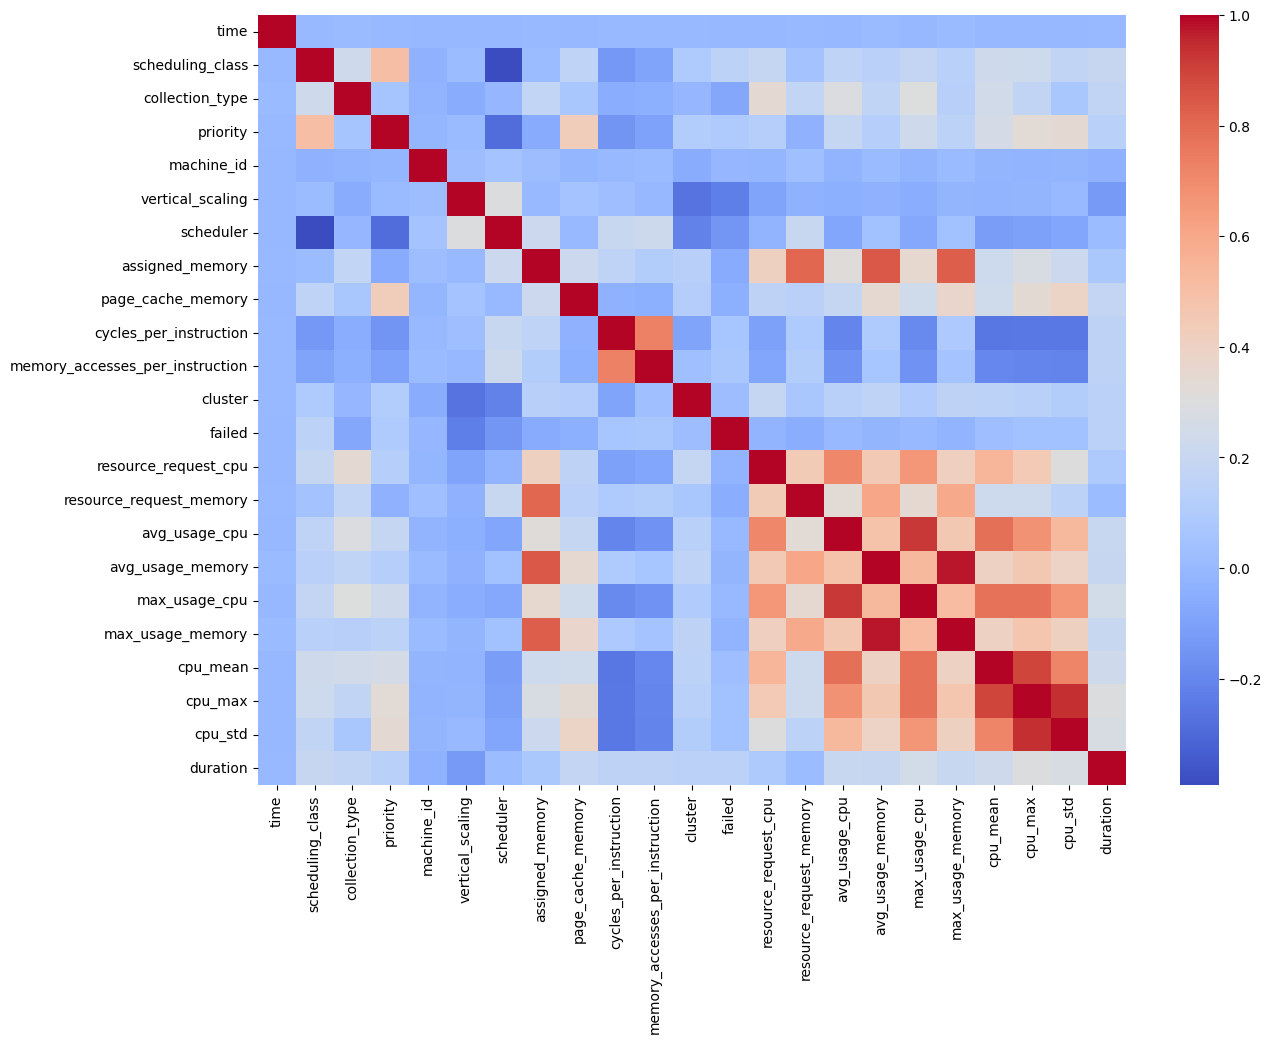

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = events_sorted.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

Parsed cpu and memory feature are highly redundant

In [26]:
corr.loc[:, ["assigned_memory", "avg_usage_memory", "avg_usage_cpu", "max_usage_memory", "max_usage_cpu", "cpu_mean", "cpu_max", "cpu_std"]]

,assigned_memory,avg_usage_memory,avg_usage_cpu,max_usage_memory,max_usage_cpu,cpu_mean,cpu_max,cpu_std
time,0.004325,0.006649,-0.001002,0.006618,-0.001218,-0.001202,-0.001485,-0.001495
scheduling_class,0.013445,0.139896,0.161856,0.135101,0.183644,0.230768,0.227568,0.171735
collection_type,0.173856,0.163446,0.291930,0.128986,0.299224,0.238922,0.168525,0.066693
priority,-0.063552,0.124080,0.187796,0.148480,0.232455,0.259447,0.333011,0.342886
machine_id,0.016497,0.008468,-0.025253,0.007114,-0.026216,-0.022144,-0.023042,-0.019438
vertical_scaling,0.001074,-0.033721,-0.043548,-0.019648,-0.053653,-0.025900,-0.019300,0.001709
scheduler,0.214399,0.042884,-0.083716,0.041848,-0.071877,-0.117244,-0.105099,-0.082816
assigned_memory,1.000000,0.847234,0.316331,0.828924,0.353825,0.227761,0.275056,0.211781
page_cache_memory,0.215903,0.351741,0.186798,0.373522,0.234483,0.235822,0.340651,0.388225
cycles_per_instruction,0.157574,0.093594,-0.204460,0.082521,-0.185894,-0.251760,-0.245190,-0.246019


In [27]:
events_sorted.drop(["max_usage_memory", "assigned_memory", "avg_usage_cpu", "cpu_mean", "cpu_max"], axis=1)
events_sorted.columns

Index(['time', 'scheduling_class', 'collection_type', 'priority', 'machine_id',
       'vertical_scaling', 'scheduler', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction', 'cluster',
       'failed', 'resource_request_cpu', 'resource_request_memory',
       'avg_usage_cpu', 'avg_usage_memory', 'max_usage_cpu',
       'max_usage_memory', 'cpu_mean', 'cpu_max', 'cpu_std', 'duration'],
      dtype='str')

Feature correlations suggest nonlinear model is better

In [28]:
events_sorted.loc[:, ['time', 'scheduling_class', 'collection_type', 'priority',
       'vertical_scaling', 'scheduler', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction']].describe()

,time,scheduling_class,collection_type,priority,vertical_scaling,scheduler,assigned_memory,page_cache_memory,cycles_per_instruction
count,4.058940e+05,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000
mean,6.927465e+07,1.266870,0.087782,147.913793,1.859074,0.369547,0.008927,0.000398,2.103451
std,2.507511e+10,1.014087,0.282977,116.656633,0.753907,0.482683,0.024937,0.000550,1.052743
min,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.252846
25%,2.674747e+05,0.000000,0.000000,103.000000,1.000000,0.000000,0.000196,0.000008,1.354252
50%,1.084800e+06,1.000000,0.000000,105.000000,2.000000,0.000000,0.002693,0.000227,1.918681
75%,1.766117e+06,2.000000,0.000000,200.000000,2.000000,1.000000,0.006683,0.000539,2.672982
max,9.223372e+12,3.000000,1.000000,450.000000,3.000000,1.000000,0.286133,0.008453,105.275932


In [29]:
events_sorted.loc[:, ['memory_accesses_per_instruction', 'cluster',
       'failed', 'resource_request_cpu', 'resource_request_memory',
       'avg_usage_cpu', 'avg_usage_memory', 'max_usage_cpu',
       'max_usage_memory', 'cpu_mean', 'cpu_max', 'cpu_std', 'duration']].describe()

,memory_accesses_per_instruction,cluster,failed,resource_request_cpu,resource_request_memory,avg_usage_cpu,avg_usage_memory,max_usage_cpu,max_usage_memory,cpu_mean,cpu_max,cpu_std,duration
count,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000,405894.000000
mean,0.010348,4.563613,0.228331,0.015307,0.009025,0.007446,0.005640,0.025352,0.005892,0.007242,0.017005,0.004175,211.874270
std,0.006478,2.208008,0.419757,0.028626,0.022282,0.018567,0.016559,0.052681,0.016538,0.014937,0.028101,0.006880,129.227356
min,0.000125,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.006084,3.000000,0.000000,0.004051,0.001303,0.000200,0.000238,0.000794,0.000282,0.000216,0.000683,0.000164,41.000000
50%,0.009506,5.000000,0.000000,0.008102,0.003254,0.001049,0.001282,0.005005,0.001444,0.000915,0.002995,0.000702,300.000000
75%,0.013702,6.000000,0.000000,0.015839,0.006508,0.007286,0.004257,0.029724,0.004616,0.007936,0.023560,0.005508,300.000000
max,0.084292,8.000000,1.000000,0.583008,0.286621,0.538086,0.223877,1.271484,0.224365,0.245617,0.432129,0.103910,300.000000


### Model training

In [30]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [ ]:
from preprocessing import process_df

train_raw = pd.read_parquet("/home/maria/Projects/BigData_labs/lab_1/data/split/train_raw.parquet")
val_raw = pd.read_parquet("/home/maria/Projects/BigData_labs/lab_1/data/split/val_raw.parquet")

with open("/home/maria/Projects/BigData_labs/lab_1/data/artifacts/medians.json", "r") as f:
    medians = json.load(f)

train_df, _ = process_df(train_raw, medians, train=True)
val_df, _ = process_df(val_raw, medians, train=True)

Index(['time', 'priority', 'vertical_scaling', 'assigned_memory',
       'page_cache_memory', 'cycles_per_instruction',
       'memory_accesses_per_instruction', 'failed', 'resource_request_cpu',
       'resource_request_memory', 'avg_usage_cpu', 'avg_usage_memory',
       'max_usage_cpu', 'max_usage_memory', 'cpu_mean', 'cpu_max', 'cpu_std',
       'duration'],
      dtype='str')

In [ ]:
X_train = train_df.drop("failed", axis=1)
y_train = train_df["failed"]

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

model.fit(X_train, y_train)
joblib.dump(model, "/home/maria/Projects/BigData_labs/lab_1/ml_consumer/artifacts/random_forest.pkl")

['/home/maria/Projects/BigData_labs/lab_1/classification_model/random_forest.pkl']

In [33]:
X_val = val_df.drop("failed", axis=1)
y_val = val_df["failed"]
y_pred = model.predict(X_val)

f1 = f1_score(y_val, y_pred)

print("Validation F1 Score:", f1)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Validation F1 Score: 0.9909081069379803

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31321
           1       0.99      0.99      0.99      9268

    accuracy                           1.00     40589
   macro avg       1.00      0.99      0.99     40589
weighted avg       1.00      1.00      1.00     40589


Confusion Matrix:
[[31266    55]
 [  113  9155]]


In [34]:
importances = model.feature_importances_
features = X_train.columns

importance_df = (
    pd.DataFrame({"feature": features, "importance": importances})
    .sort_values(by="importance", ascending=False)
)

print("\nImportant Features Rating:")
print(importance_df)


Important Features Rating:
                            feature  importance
0                              time    0.136415
4                 page_cache_memory    0.071373
14                          cpu_max    0.068391
15                          cpu_std    0.068387
5            cycles_per_instruction    0.067487
10                 avg_usage_memory    0.062630
6   memory_accesses_per_instruction    0.062404
13                         cpu_mean    0.057604
11                    max_usage_cpu    0.057543
12                 max_usage_memory    0.056613
9                     avg_usage_cpu    0.054673
7              resource_request_cpu    0.050819
3                   assigned_memory    0.047983
2                  vertical_scaling    0.040298
1                          priority    0.038997
8           resource_request_memory    0.033226
16                         duration    0.025158


Least iportant features like "collection_type", "sample_rate", "scheduler" and "scheduling_class" can be removed too. \
I will update preprocessing script, so with current launch these features will no longer be there